In [43]:
# Libraries laden
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Vaste seed: resultaten blijven beter vergelijkbaar
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [44]:
# Pad naar het Excel-bestand met de Ames Housing dataset
file_path = Path("AmesHousing.xlsx")

# Lees het Excel-bestand in als Pandas DataFrame
df = pd.read_excel(file_path)

# Toon de eerste 5 rijen
df.head()

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [45]:
# Controle van de dataset
print("Aantal rijen en kolommen:", df.shape)
print("Kolommen:", list(df.columns))

# SalePrice is wat we willen voorspellen
print("Laagste prijs:", df["SalePrice"].min())
print("Hoogste prijs:", df["SalePrice"].max())

Aantal rijen en kolommen: (2930, 12)
Kolommen: ['ID', 'SalePrice', 'Garage', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood', 'House Style']
Laagste prijs: 12789
Hoogste prijs: 755000


In [46]:
# Kolom die het model later moet voorspellen
target_column = "SalePrice"

# Features zijn alle kolommen behalve de target
feature_df = df.drop(columns=[target_column])

# Splits de inputkolommen op basis van datatype.
# Dit is nodig omdat numerieke en categorische kolommen later anders worden voorbereid.
numeric_columns = feature_df.select_dtypes(include=["number"]).columns
categorical_columns = feature_df.select_dtypes(
    include=["object", "category", "string", "str"]
).columns

print("Numerieke kolommen:")
print(list(numeric_columns))

print("\nCategorische kolommen:")
print(list(categorical_columns))

Numerieke kolommen:
['ID', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr']

Categorische kolommen:
['Garage', 'Neighborhood', 'House Style']


In [47]:
# Split de dataset in train/validation en een aparte testset.
# 20% van de data wordt apart gehouden voor de eindtest.
train_validation_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED
)

# Controleer hoeveel records in beide subsets zitten
print("Train + validation:", train_validation_df.shape)
print("Test:", test_df.shape)

Train + validation: (2344, 12)
Test: (586, 12)


In [48]:
# Garage-kolommen selecteren als ze bestaan in de dataset
garage_features = [
    column for column in ["Garage Cars", "Garage Area", "Garage Yr Blt"]
    if column in df.columns
]

# Feature-sets voor verschillende experimenten
feature_sets = {
    "Basis": [
        "Overall Qual", "Gr Liv Area", "Year Built"
    ],

    "Meer numeriek": [
        "Overall Qual", "Gr Liv Area", "Total Bsmt SF",
        "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr"
    ],

    # Zelfde als "Meer numeriek", maar met beschikbare garage-informatie
    "Numeriek + garage": [
        "Overall Qual", "Gr Liv Area", "Total Bsmt SF",
        "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr",
        *garage_features
    ],

    # Gebruik alle kolommen als input, behalve ID en de target
    "Alle features": [
        column for column in df.columns if column not in ["ID", target_column]
    ]
}

# Controleer hoeveel features per experiment worden gebruikt
for name, features in feature_sets.items():
    print(name, "=", len(features), "features")

Basis = 3 features
Meer numeriek = 7 features
Numeriek + garage = 7 features
Alle features = 10 features


In [49]:
def make_one_hot_encoder():
    # Gebruik de juiste parameter voor de geïnstalleerde scikit-learn versie
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def create_preprocessor(X_train):
    # Bepaal welke kolommen numeriek of categorisch zijn
    numeric_columns = X_train.select_dtypes(include=["number"]).columns
    categorical_columns = X_train.select_dtypes(
        include=["object", "category", "string", "str"]
    ).columns

    # Numerieke data: missende waarden invullen en waarden schalen
    numeric_pipeline = Pipeline([
        ("fill_missing", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    # Categorische data: missende waarden invullen en tekst omzetten naar getallen
    categorical_pipeline = Pipeline([
        ("fill_missing", SimpleImputer(strategy="most_frequent")),
        ("one_hot", make_one_hot_encoder())
    ])

    # Combineer beide pipelines: elke kolomgroep krijgt de juiste preprocessing
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ])

In [50]:
def prepare_data(feature_names, validation_size=0.20):
    # Selecteer de gekozen features als input en SalePrice als target
    X_train_validation = train_validation_df[feature_names]
    y_train_validation = train_validation_df[target_column]

    X_test = test_df[feature_names]
    y_test = test_df[target_column]

    # Split de train/validation-set opnieuw in echte trainingsdata en validatiedata
    X_train, X_validation, y_train, y_validation = train_test_split(
        X_train_validation,
        y_train_validation,
        test_size=validation_size,
        random_state=SEED
    )

    # Maak de preprocessing pipeline op basis van de trainingsdata
    preprocessor = create_preprocessor(X_train)

    # Fit alleen op trainingsdata om data leakage te voorkomen
    X_train_ready = preprocessor.fit_transform(X_train)
    X_validation_ready = preprocessor.transform(X_validation)
    X_test_ready = preprocessor.transform(X_test)

    return X_train_ready, X_validation_ready, X_test_ready, y_train, y_validation, y_test

In [51]:
# Test of preprocessing werkt met tekst en getallen
X_train_ready, X_validation_ready, X_test_ready, y_train, y_validation, y_test = prepare_data(
    feature_sets["Alle features"],
    validation_size=0.20
)

print("Train input:", X_train_ready.shape)
print("Validation input:", X_validation_ready.shape)
print("Test input:", X_test_ready.shape)
print("Train target:", y_train.shape)

Train input: (1875, 45)
Validation input: (469, 45)
Test input: (586, 45)
Train target: (1875,)


In [52]:
def calculate_scores(y_true, y_pred):
    # MAE/RMSE lager is beter, R2 hoger is beter
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [53]:
def test_linear_regression(feature_set_name, validation_size=0.20):
    # Haal de gekozen feature-set op voor dit experiment
    features = feature_sets[feature_set_name]

    # Bereid train-, validation- en testdata voor
    X_train, X_validation, X_test, y_train, y_validation, y_test = prepare_data(
        features,
        validation_size
    )

    # Train een Linear Regression model als baseline
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Maak voorspellingen voor validatie en test
    validation_predictions = model.predict(X_validation)
    test_predictions = model.predict(X_test)

    # Bereken prestaties op validation en test
    validation_scores = calculate_scores(y_validation, validation_predictions)
    test_scores = calculate_scores(y_test, test_predictions)

    # Geef de belangrijkste resultaten terug voor de vergelijkingstabel
    return {
        "Model": "Linear Regression",
        "Feature set": feature_set_name,
        "Validation size": validation_size,
        "Validation MAE": round(validation_scores["MAE"], 2),
        "Test MAE": round(test_scores["MAE"], 2),
        "Test RMSE": round(test_scores["RMSE"], 2),
        "Test R2": round(test_scores["R2"], 4)
    }

In [54]:
# Test Linear Regression met elke feature-set
linear_results = []

for feature_set_name in feature_sets:
    result = test_linear_regression(feature_set_name)
    linear_results.append(result)

# Zet alle resultaten in een tabel en sorteer op laagste Test MAE
# Lagere MAE betekent dat het model gemiddeld minder fout zit in de prijsvoorspelling
linear_results_table = pd.DataFrame(linear_results).sort_values("Test MAE")

linear_results_table

,Model,Feature set,Validation size,Validation MAE,Test MAE,Test RMSE,Test R2
3,Linear Regression,Alle features,0.2,18994.99,21731.95,36079.57,0.8376
1,Linear Regression,Meer numeriek,0.2,20898.11,25076.10,40105.34,0.7994
2,Linear Regression,Numeriek + garage,0.2,20898.11,25076.10,40105.34,0.7994
0,Linear Regression,Basis,0.2,24837.28,29078.05,44261.08,0.7557


In [55]:
def create_house_model(input_size, hidden_layers, learning_rate):
    # Bouw een neural network voor regressie: het model voorspelt één verkoopprijs
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_size,)))

    # Voeg de gekozen hidden layers toe
    # Voorbeeld: [128, 64] maakt twee Dense-lagen met 128 en 64 nodes
    for nodes in hidden_layers:
        model.add(tf.keras.layers.Dense(nodes, activation="relu"))

    # Output layer: één waarde, namelijk de voorspelde SalePrice
    model.add(tf.keras.layers.Dense(1))

    # MSE wordt gebruikt als loss; MAE is leesbaar als gemiddelde fout in prijs
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [56]:
def test_neural_network(experiment):
    # Zet seeds opnieuw, zodat experimenten beter vergelijkbaar blijven
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # Haal de feature-set op die bij dit experiment hoort
    features = feature_sets[experiment["feature_set"]]

    # Bereid train-, validation- en testdata voor
    X_train, X_validation, X_test, y_train, y_validation, y_test = prepare_data(
        features,
        experiment["validation_size"]
    )

    # Schaal de targetwaarden, zodat het neural network stabieler leert
    y_mean = y_train.mean()
    y_std = y_train.std()

    y_train_scaled = (y_train - y_mean) / y_std
    y_validation_scaled = (y_validation - y_mean) / y_std

    # Maak een neural network met de instellingen van dit experiment
    model = create_house_model(
        input_size=X_train.shape[1],
        hidden_layers=experiment["hidden_layers"],
        learning_rate=experiment["learning_rate"]
    )

    # Stop training als de validation loss niet meer verbetert
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    # Train het model op geschaalde verkoopprijzen
    history = model.fit(
        X_train,
        y_train_scaled,
        epochs=experiment["epochs"],
        batch_size=experiment["batch_size"],
        validation_data=(X_validation, y_validation_scaled),
        callbacks=[early_stop],
        verbose=0
    )

    # Voorspellingen terugschalen naar echte verkoopprijzen
    validation_pred_scaled = model.predict(X_validation, verbose=0).ravel()
    test_pred_scaled = model.predict(X_test, verbose=0).ravel()

    validation_predictions = validation_pred_scaled * y_std + y_mean
    test_predictions = test_pred_scaled * y_std + y_mean

    # Bereken regressie-scores op validation en test
    validation_scores = calculate_scores(y_validation, validation_predictions)
    test_scores = calculate_scores(y_test, test_predictions)

    # Resultaten teruggeven voor de vergelijkingstabel
    return {
        "Experiment": experiment["name"],
        "Feature set": experiment["feature_set"],
        "Hidden layers": str(experiment["hidden_layers"]),
        "Learning rate": experiment["learning_rate"],
        "Epochs max": experiment["epochs"],
        "Epochs gebruikt": len(history.history["loss"]),
        "Batch size": experiment["batch_size"],
        "Validation size": experiment["validation_size"],
        "Validation MAE": round(validation_scores["MAE"], 2),
        "Test MAE": round(test_scores["MAE"], 2),
        "Test RMSE": round(test_scores["RMSE"], 2),
        "Test R2": round(test_scores["R2"], 4)
    }

In [57]:
# Experimentconfiguraties voor het neural network.
# Per experiment wijzigen we één onderdeel, zoals feature-set, netwerkstructuur,
# learning rate, epochs, validation size of batch size.
experiments = [
    # Feature-sets vergelijken
    {"name": "E01 Basis", "feature_set": "Basis", "hidden_layers": [64, 32], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E02 Meer numeriek", "feature_set": "Meer numeriek", "hidden_layers": [64, 32], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E03 Numeriek + garage", "feature_set": "Numeriek + garage", "hidden_layers": [64, 32], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E04 Alle features", "feature_set": "Alle features", "hidden_layers": [64, 32], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},

    # Aantal hidden layers vergelijken
    {"name": "E05 1 laag", "feature_set": "Alle features", "hidden_layers": [64], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E06 2 lagen", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E07 3 lagen", "feature_set": "Alle features", "hidden_layers": [128, 64, 32], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},

    # Grootte van het neural network vergelijken
    {"name": "E08 Klein NN", "feature_set": "Alle features", "hidden_layers": [32, 16], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E09 Groot NN", "feature_set": "Alle features", "hidden_layers": [256, 128], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.20},

    # Learning rate vergelijken
    {"name": "E10 LR 0.0005", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.0005, "epochs": 80, "batch_size": 32, "validation_size": 0.20},
    {"name": "E11 LR 0.005", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.005, "epochs": 80, "batch_size": 32, "validation_size": 0.20},

    # Maximum aantal epochs vergelijken
    # Early stopping kan ervoor zorgen dat het model eerder stopt.
    {"name": "E12 Epochs 40", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 40, "batch_size": 32, "validation_size": 0.20},
    {"name": "E13 Epochs 120", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 120, "batch_size": 32, "validation_size": 0.20},

    # Grootte van de validatieset vergelijken
    {"name": "E14 Validation 10%", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.10},
    {"name": "E15 Validation 30%", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 80, "batch_size": 32, "validation_size": 0.30},

    # Batch size vergelijken
    {"name": "E16 Batch 16", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 80, "batch_size": 16, "validation_size": 0.20},
    {"name": "E17 Batch 64", "feature_set": "Alle features", "hidden_layers": [128, 64], "learning_rate": 0.001, "epochs": 80, "batch_size": 64, "validation_size": 0.20},
]

# Controleer hoeveel experimenten worden uitgevoerd
print("Aantal experimenten:", len(experiments))

Aantal experimenten: 17


In [58]:
# Voer alle neural-network-experimenten uit
nn_results = []

for experiment in experiments:
    print("Bezig met:", experiment["name"])

    # Train en evalueer één experiment, en sla het resultaat op
    result = test_neural_network(experiment)
    nn_results.append(result)

# Zet alle resultaten in een tabel en sorteer op laagste Test MAE
# Lagere MAE betekent een kleinere gemiddelde voorspelfout
nn_results_table = pd.DataFrame(nn_results).sort_values("Test MAE")

nn_results_table

Bezig met: E01 Basis
Bezig met: E02 Meer numeriek
Bezig met: E03 Numeriek + garage
Bezig met: E04 Alle features
Bezig met: E05 1 laag
Bezig met: E06 2 lagen
Bezig met: E07 3 lagen
Bezig met: E08 Klein NN
Bezig met: E09 Groot NN
Bezig met: E10 LR 0.0005
Bezig met: E11 LR 0.005
Bezig met: E12 Epochs 40
Bezig met: E13 Epochs 120
Bezig met: E14 Validation 10%
Bezig met: E15 Validation 30%
Bezig met: E16 Batch 16
Bezig met: E17 Batch 64


,Experiment,Feature set,Hidden layers,Learning rate,Epochs max,Epochs gebruikt,Batch size,Validation size,Validation MAE,Test MAE,Test RMSE,Test R2
5,E06 2 lagen,Alle features,"[128, 64]",0.0010,80,21,32,0.2,15613.50,16866.47,27075.70,0.9086
11,E12 Epochs 40,Alle features,"[128, 64]",0.0010,40,21,32,0.2,15613.50,16866.47,27075.70,0.9086
12,E13 Epochs 120,Alle features,"[128, 64]",0.0010,120,21,32,0.2,15613.50,16866.47,27075.70,0.9086
6,E07 3 lagen,Alle features,"[128, 64, 32]",0.0010,80,17,32,0.2,15731.69,16904.01,27634.49,0.9048
9,E10 LR 0.0005,Alle features,"[128, 64]",0.0005,80,28,32,0.2,15840.09,17070.40,27404.08,0.9063
15,E16 Batch 16,Alle features,"[128, 64]",0.0010,80,15,16,0.2,15781.21,17389.45,28031.92,0.9020
8,E09 Groot NN,Alle features,"[256, 128]",0.0010,80,13,32,0.2,15377.26,17523.48,28348.61,0.8998
16,E17 Batch 64,Alle features,"[128, 64]",0.0010,80,17,64,0.2,15795.56,17700.20,27884.56,0.9030
13,E14 Validation 10%,Alle features,"[128, 64]",0.0010,80,11,32,0.1,16375.03,18028.91,29477.13,0.8916
14,E15 Validation 30%,Alle features,"[128, 64]",0.0010,80,36,32,0.3,17508.85,18180.71,28385.09,0.8995


In [59]:
# Selecteer het beste model uit beide resultaat-tabellen.
# Beide tabellen zijn eerder gesorteerd op laagste Test MAE.
best_linear = linear_results_table.iloc[0]
best_nn = nn_results_table.iloc[0]

# Vergelijk de beste Linear Regression met het beste Neural Network
comparison_table = pd.DataFrame([
    {
        "Model": "Beste Linear Regression",
        "Feature set": best_linear["Feature set"],
        "Test MAE": best_linear["Test MAE"],
        "Test RMSE": best_linear["Test RMSE"],
        "Test R2": best_linear["Test R2"]
    },
    {
        "Model": "Beste Neural Network",
        "Feature set": best_nn["Feature set"],
        "Test MAE": best_nn["Test MAE"],
        "Test RMSE": best_nn["Test RMSE"],
        "Test R2": best_nn["Test R2"]
    }
])

# Sorteer op laagste MAE, zodat het model met de kleinste gemiddelde fout bovenaan staat
comparison_table = comparison_table.sort_values("Test MAE")

comparison_table

,Model,Feature set,Test MAE,Test RMSE,Test R2
1,Beste Neural Network,Alle features,16866.47,27075.70,0.9086
0,Beste Linear Regression,Alle features,21731.95,36079.57,0.8376


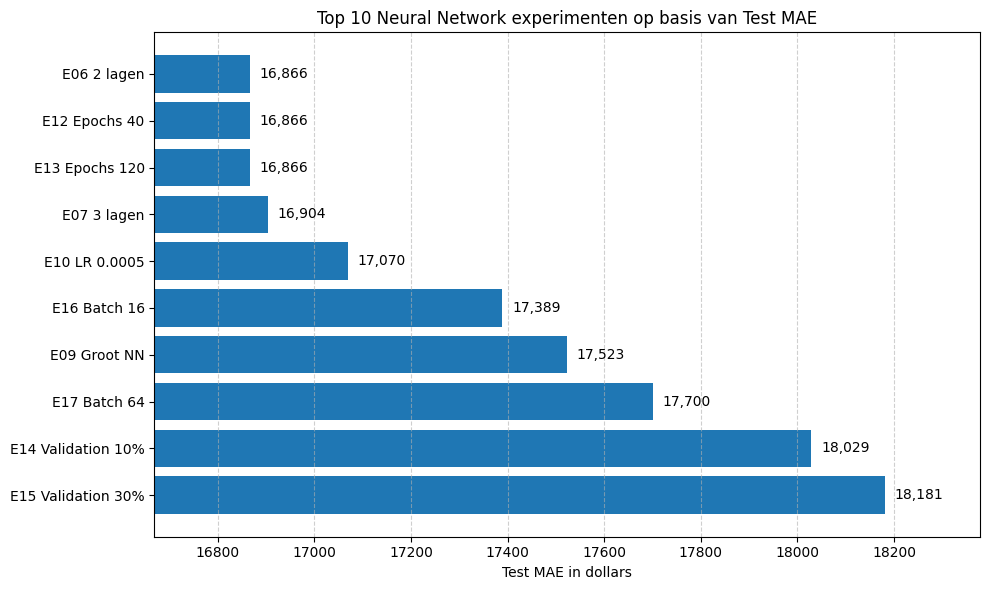

In [62]:
# Selecteer de 10 beste experimenten op basis van Test MAE
best_10 = nn_results_table.nsmallest(10, "Test MAE").copy()
best_10 = best_10.sort_values("Test MAE", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(best_10["Experiment"], best_10["Test MAE"])

# Beste experiment bovenaan
plt.gca().invert_yaxis()

# Zoom in op het relevante bereik, zodat kleine verschillen zichtbaar worden
min_mae = best_10["Test MAE"].min()
max_mae = best_10["Test MAE"].max()
margin = (max_mae - min_mae) * 0.15 if max_mae > min_mae else 500
plt.xlim(min_mae - margin, max_mae + margin)

# Waarden naast de bars tonen
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center"
    )

plt.xlabel("Test MAE in dollars")
plt.title("Top 10 Neural Network experimenten op basis van Test MAE")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [61]:
# Pak het beste model uit de vergelijkingstabel.
# De tabel is eerder gesorteerd op laagste Test MAE.
best_model = comparison_table.iloc[0]

# Toon de belangrijkste resultaten
print("Beste feature-set NN:", best_nn["Feature set"])
print("Beste NN Test MAE:", best_nn["Test MAE"])
print("Beste Linear Regression Test MAE:", best_linear["Test MAE"])
print("Beste model:", best_model["Model"])

# Trek automatisch een conclusie op basis van de laagste Test MAE
if best_nn["Test MAE"] < best_linear["Test MAE"]:
    print("Conclusie: het Neural Network voorspelt beter dan Linear Regression.")
elif best_nn["Test MAE"] > best_linear["Test MAE"]:
    print("Conclusie: Linear Regression voorspelt beter dan het Neural Network.")
else:
    print("Conclusie: beide modellen presteren ongeveer gelijk.")

Beste feature-set NN: Alle features
Beste NN Test MAE: 16866.47
Beste Linear Regression Test MAE: 21731.95
Beste model: Beste Neural Network
Conclusie: het Neural Network voorspelt beter dan Linear Regression.
